<a href="https://colab.research.google.com/github/deepakk7195/IISC_CDS_DS/blob/Scalable_ML_GenAI/MiniProject_02_Fare_Amount_Prediction_Using_Dask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Program in Computational Data Science
## A program by IISc and TalentSprint
### Mini-Project: Implementation of Linear Regression on a Large Dataset Using Dask Library

## Learning Objectives

At the end of the mini-project, you will be able to :

- understand how dask handles large dataset over pandas dataframe
- perform exploratory data analysis on a large dataset (2 Million rows) using dask
- implement linear regression model using dask library and make predictions


## Problem Statement

 Predict the taxi fare amount in New York city using Dask-ML.

## Information

### Dask
[Dask](https://dask.pydata.org/en/latest/) is an open source project that gives abstractions over NumPy Arrays, Pandas Dataframes and regular lists, allowing you to run operations on them in parallel, using multicore processing.

We can summarize the basics of Dask as follows:

* processes data that doesn’t fit into memory by breaking it into blocks and specifying task chains

* parallelizes execution of tasks across cores and even nodes of a cluster

* moves computation to the data rather than the other way around, to minimize communication overhead

### Dataset

The dataset is based on the 2016 NYC Yellow Cab trip record data made available in Big Query on Google Cloud Platform. Its variables are as follows:
![Dataset](https://cdn.iisc.talentsprint.com/CDS/Images/NYC_Taxi_data_description.png)




Note that the features the ' Dask_MP_dataset.csv' file that is provided for this miniproject varies slightly in terms of included features, as compared to the original dataset described above. Please proceed with the provided csv file.

## Grading = 10 Points

In [ ]:
#@title Install Dask dependencies and restart runtime
!pip -qq install dask-ml
!pip -qq install dask
!pip -qq install dask[complete]
!pip -qq install dask distributed
!pip -qq install mimesis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.8/149.8 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 20.2 MB/s eta 0:00:00


#### Importing Necessary Packages

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import dask
import dask.dataframe as dd
import dask.array as da
from dask_ml.linear_model import LinearRegression
from dask_ml.model_selection import train_test_split
from dask_ml.metrics import mean_squared_error, r2_score
from dask.distributed import Client
import time as time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from dask.distributed import Client, progress
client = Client()

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:36631
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:32773'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:41839'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:41005'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:36093'
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://127.0.0.1:44675', name: 3, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:44675
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:43656
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://127.0.0.1:38955', name: 2, stat

In [ ]:
#@title Download the data
!wget https://cdn.iisc.talentsprint.com/CDS/MiniProjects/Dask_MP_dataset.csv

--2024-04-28 07:00:15--  https://cdn.iisc.talentsprint.com/CDS/MiniProjects/Dask_MP_dataset.csv
Resolving cdn.iisc.talentsprint.com (cdn.iisc.talentsprint.com)... 172.105.52.210
Connecting to cdn.iisc.talentsprint.com (cdn.iisc.talentsprint.com)|172.105.52.210|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 231900522 (221M) [application/octet-stream]
Saving to: ‘Dask_MP_dataset.csv’

Dask_MP_dataset.csv 100%[===================>] 221.16M  10.9MB/s    in 21s     

2024-04-28 07:00:37 (10.5 MB/s) - ‘Dask_MP_dataset.csv’ saved [231900522/231900522]



#### Exercise 1: Read the dataset using dask library and compare the time of execution with pandas library.

**Hint:** pass `dtype` for passenger_count as `int64`

In [ ]:
%%time
# YOUR CODE HERE

# Compute the time taken to read the dataset using Dask
start_time_dask = time.time()
df_dask = dd.read_csv('/content/Dask_MP_dataset.csv', dtype={'passenger_count': 'int64'})
end_time_dask = time.time()
time_taken_dask = end_time_dask - start_time_dask

print('Time taken to read the dataset using Dask:', time_taken_dask)

Time taken to read the dataset using Dask: 0.054593563079833984
CPU times: user 26.7 ms, sys: 4.69 ms, total: 31.4 ms
Wall time: 54.8 ms


#### Use pandas to read the dataset and compare the time taken

In [ ]:
%%time
# YOUR CODE HERE
# Compute the time taken to read the dataset using Pandas
start_time_pandas = time.time()
df_pandas = pd.read_csv('/content/Dask_MP_dataset.csv', dtype={'passenger_count': 'int64'})
end_time_pandas = time.time()
time_taken_pandas = end_time_pandas - start_time_pandas

print('Time taken to read the dataset using Pandas:', time_taken_pandas)

Time taken to read the dataset using Pandas: 4.0988945960998535
CPU times: user 3.8 s, sys: 442 ms, total: 4.24 s
Wall time: 4.1 s


### Data Analysis (2 Points)



#### Exercise 2: Drop the unnecessary columns. Also drop the duplicate rows and the rows having null values.

**Hint:** Drop those columns which are not useful in EDA as well as model implementation

In [ ]:
df_dask.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


In [ ]:
columns_to_drop = ['Unnamed: 0', 'key']
df_dask = df_dask.drop(columns=columns_to_drop)

In [ ]:
df_dask.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


In [ ]:
""" Drop duplicate rows """
# YOUR CODE HERE
df_dask = df_dask.drop_duplicates()

In [ ]:
shape = df_dask.compute().shape

print("Shape of the dataframe:", shape)

Shape of the dataframe: (1999997, 7)


In [ ]:
""" drop NA rows """
# YOUR CODE HERE
df_dask = df_dask.dropna()

In [ ]:
shape = df_dask.compute().shape

print("Shape of the dataframe:", shape)

Shape of the dataframe: (1999983, 7)


#### Exercise 3: Visualize the target variable, i.e., `fare_amount` to study the fare distribution, using a histogram density plot. Analyze the fare_amount distribution, try to visualize it for a range of [0, 60].

**Hint:** [sns.hisplot()](https://stackoverflow.com/questions/51027636/seaborn-histogram-with-bigdata/51027895) and use `.between` to plot the graph for given range


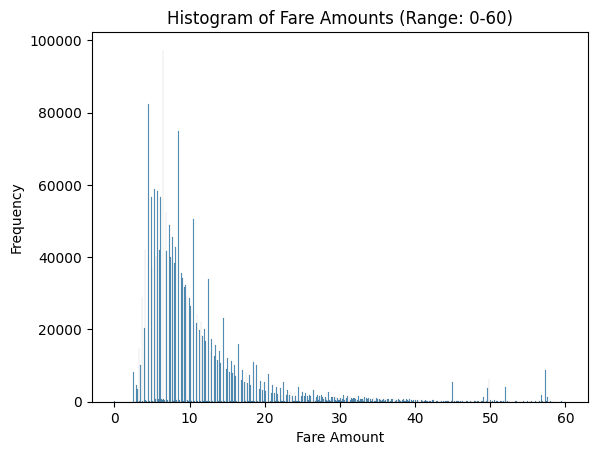

In [ ]:
""" explore and plot the density plot of fare_amount """
# YOUR CODE HERE
df_pandas = df_dask.compute()

# Filter the data for the specified range [0, 60]
filtered_data = df_pandas[df_pandas['fare_amount'].between(0, 60)]

# Plot the histogram
sns.histplot(filtered_data['fare_amount'])
plt.xlabel('Fare Amount')
plt.ylabel('Frequency')
plt.title('Histogram of Fare Amounts (Range: 0-60)')
plt.show()

#### Observe the number of workers and cores running in your machine

Initialize a client and observe how many workers are working and the number of cores utilizing for the given data set.

In [ ]:
""" Initialize a client """
# YOUR CODE HERE
# Check the number of workers
num_workers = len(client.scheduler_info()['workers'])

# Check the total number of cores
total_cores = sum(client.ncores().values())

print("Number of workers:", num_workers)
print("Total number of cores:", total_cores)

Number of workers: 4
Total number of cores: 16


### EDA based on Time (2 Points)

#### Exercise 4: Extract day of the week (dow), hour, month and year from `pickup_datetime`.

**Hint:** use `pd.to_datetime()` function as dask does not have this functionality in it.

Remember to use `.compute()` while passing the dask dataframe in defined function.

In [ ]:
# YOUR CODE HERE
def extract_datetime_features(df_dask):
    # Convert pickup_datetime to datetime format
    df_dask['pickup_datetime'] = dd.to_datetime(df_dask['pickup_datetime'])

    # Extract features
    df_dask['dow'] = df_dask['pickup_datetime'].dt.dayofweek
    df_dask['hour'] = df_dask['pickup_datetime'].dt.hour
    df_dask['month'] = df_dask['pickup_datetime'].dt.month
    df_dask['year'] = df_dask['pickup_datetime'].dt.year

    return df_dask

# Apply the function to the Dask DataFrame
df_with_datetime_features = extract_datetime_features(df_dask).compute()
df_with_datetime_features.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,dow,hour,month,year
0,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1,0,17,6,2009
1,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1,1,16,1,2010
2,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2,3,0,8,2011
3,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1,5,4,4,2012
4,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1,1,7,3,2010


#### Exercise 5: a.) Plot the taxi trip by hour of the day

* Partition the data into segments using `dask.from_pandas()`

* Plot the taxi trip for hour of the day. **Hint:** [sns.catplot](https://seaborn.pydata.org/generated/seaborn.catplot.html)

<Figure size 1000x600 with 0 Axes>

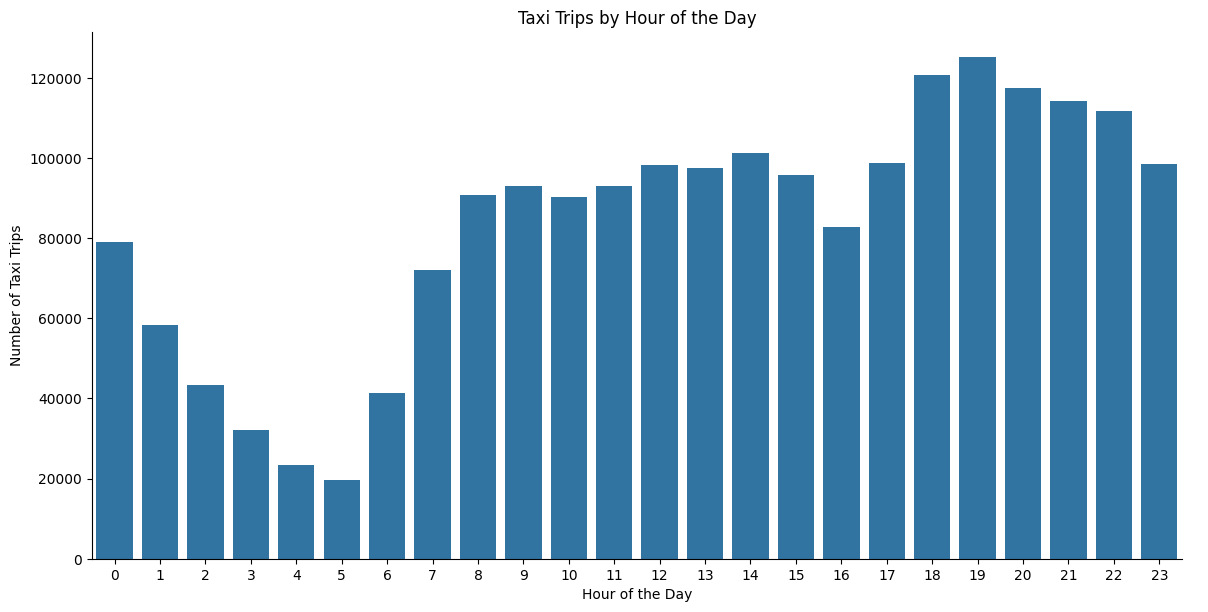

In [ ]:
""" taxi trip repartition by hour of the day """
# YOUR CODE HERE
# Partition the data into segments using dask.from_pandas()
ddf = dd.from_pandas(df_with_datetime_features, npartitions=4)  # Adjust the number of partitions as needed

# Plot the taxi trips by hour of the day
plt.figure(figsize=(10, 6))
sns.catplot(x='hour', kind='count', data=ddf.compute(), height=6, aspect=2)
plt.title('Taxi Trips by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Taxi Trips')
plt.show()

#### Exercise 5: b.) Plot the taxi trip repartition by day of the week (dow)

<Figure size 1000x600 with 0 Axes>

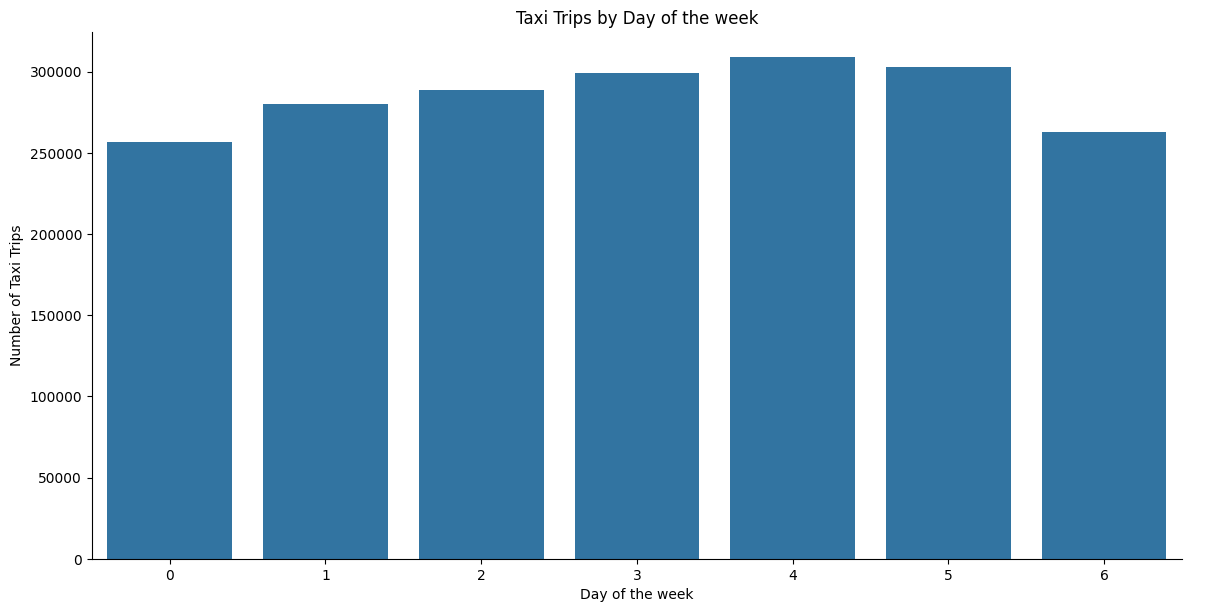

In [ ]:
""" taxi trip repartition by day of the week """
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
sns.catplot(x='dow', kind='count', data=ddf.compute(), height=6, aspect=2)
plt.title('Taxi Trips by Day of the week')
plt.xlabel('Day of the week')
plt.ylabel('Number of Taxi Trips')
plt.show()

#### Exercise 6: a.) Draw a plot between the target variable and passenger count and analyze it.

In [ ]:
df_with_datetime_features.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,dow,hour,month,year
0,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1,0,17,6,2009
1,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1,1,16,1,2010
2,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2,3,0,8,2011
3,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1,5,4,4,2012
4,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1,1,7,3,2010


INFO:distributed.core:Connection to tcp://127.0.0.1:34084 has been closed.
INFO:distributed.scheduler:Remove worker <WorkerState 'tcp://127.0.0.1:34585', name: 0, status: running, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1714286341.493696')
INFO:distributed.core:Connection to tcp://127.0.0.1:34076 has been closed.
INFO:distributed.scheduler:Remove worker <WorkerState 'tcp://127.0.0.1:40347', name: 1, status: running, memory: 0, processing: 0> (stimulus_id='handle-worker-cleanup-1714286341.5022936')
INFO:distributed.scheduler:Lost all workers
INFO:distributed.batched:Batched Comm Closed <TCP (closed) Scheduler connection to worker local=tcp://127.0.0.1:35653 remote=tcp://127.0.0.1:34076>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/distributed/comm/tcp.py", line 316, in write
    raise StreamClosedError()
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

T

KeyboardInterrupt: 

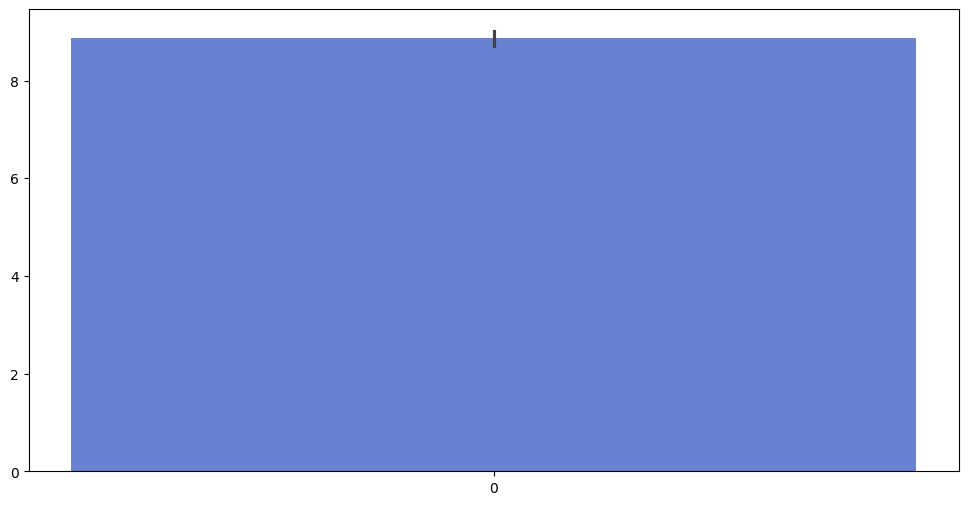

In [ ]:
# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=df_with_datetime_features['passenger_count'], y=df_with_datetime_features['fare_amount'], palette="coolwarm")

# Adding title and labels
plt.title('Fare Amount vs. Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')
plt.xticks(rotation=90)

# Display the plot
plt.show()

#### Exercise 6: b.) Draw a plot between the target variable and hour and analyze it.

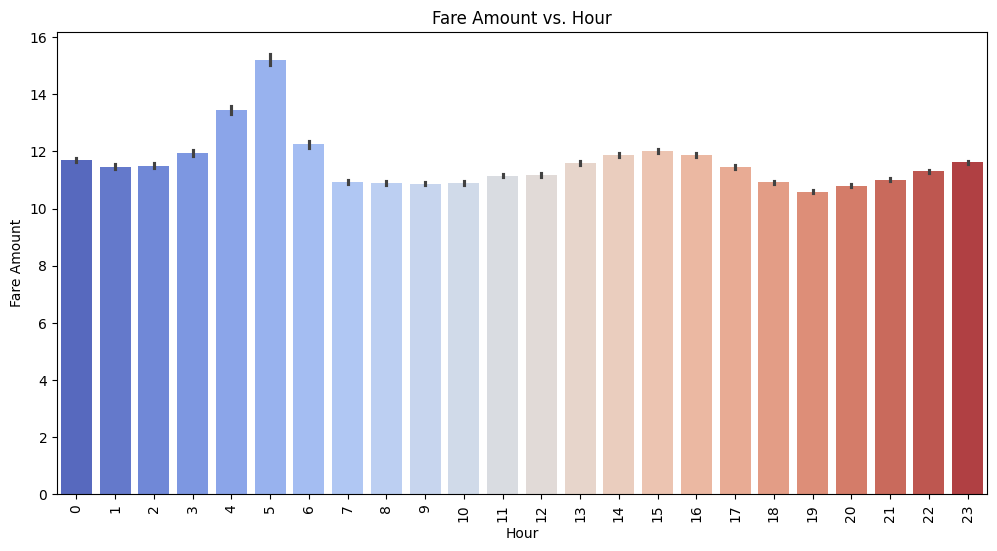

In [ ]:
""" fare amount by hour """
# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=df_with_datetime_features['hour'], y=df_with_datetime_features['fare_amount'], palette="coolwarm")
plt.title('Fare Amount vs. Hour')
plt.xlabel('Hour')
plt.ylabel('Fare Amount')
plt.xticks(rotation=90)

# Display the plot
plt.show()

### Feature Engineering (1 Point)

#### Exercise 7: Compute the Haversine distance between pickup and dropoff point

* Convert the latitude and longitude co-rodinates to radians

* Calculate the Haversine distance

  **Hint:** [haversine_distances](https://towardsdatascience.com/heres-how-to-calculate-distance-between-2-geolocations-in-python-93ecab5bbba4)

* Add the "distance" feature to the dataset and plot its distribution

In [ ]:
""" distance feature """
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    distance = 6371 * c  # Radius of the Earth in kilometers
    return distance


In [ ]:
##pick_lat =df_with_datetime_features['pickup_latitude']
##pick_lon =df_with_datetime_features['pickup_longitude']
##drop_lat =df_with_datetime_features['dropoff_latitude']
##drop_lon =df_with_datetime_features['dropoff_longitude']

# Calculate distance for each row and add the new feature distance to the dataset
df_with_datetime_features['distance'] = df_with_datetime_features.apply(lambda row: haversine(row['pickup_latitude'], row['pickup_longitude'],
                                                        row['dropoff_latitude'], row['dropoff_longitude']),axis=1)


In [ ]:
type(df_with_datetime_features)

pandas.core.frame.DataFrame

In [ ]:
# generate the dask dataframe for further processing

import pandas as pd
import dask.dataframe as dd

# Assuming you have a Pandas DataFrame named 'pdf'
ddf = dd.from_pandas(df_with_datetime_features, npartitions = 4)  # Specify number of partitions (optional)

# Explore the Dask DataFrame (might not be fully loaded in memory)
#print(ddf.head())

In [ ]:
type(ddf)

dask.dataframe.core.DataFrame

In [ ]:
ddf.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,dow,hour,month,year,distance
0,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1,0,17,6,2009,1.030764
0,7.7,2009-05-29 18:58:00+00:00,-74.006425,40.744747,-73.981225,40.769387,3,4,18,5,2009,3.465831
0,91.0,2014-09-21 10:02:20+00:00,-74.009455,40.724818,-73.965932,40.638384,1,6,10,9,2014,10.287900
1,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1,1,16,1,2010,8.450134
1,4.1,2010-08-23 14:09:16+00:00,-73.982811,40.766794,-73.982048,40.774986,1,0,14,8,2010,0.913172


In [ ]:
df_with_datetime_features.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,dow,hour,month,year,distance
0,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1,0,17,6,2009,1.030764
1,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1,1,16,1,2010,8.450134
2,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2,3,0,8,2011,1.389525
3,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1,5,4,4,2012,2.799270
4,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1,1,7,3,2010,1.999157


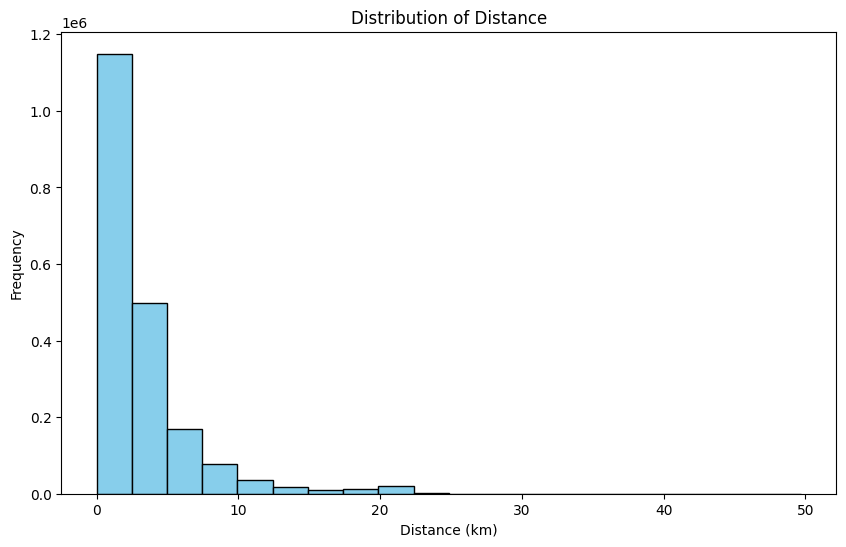

In [ ]:
""" plot the distance feature (take distance < 50) """
# Filter rows with distance less than 50 km
filtered_df = df_with_datetime_features[df_with_datetime_features['distance'] < 50]

# Plot the distance feature
plt.figure(figsize=(10, 6))
plt.hist(filtered_df['distance'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.title('Distribution of Distance')
plt.show()

### Correlation between distance and fare amount (1 Point)

INFO:distributed.core:Event loop was unresponsive in Scheduler for 5.29s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 5.29s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 5.29s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.


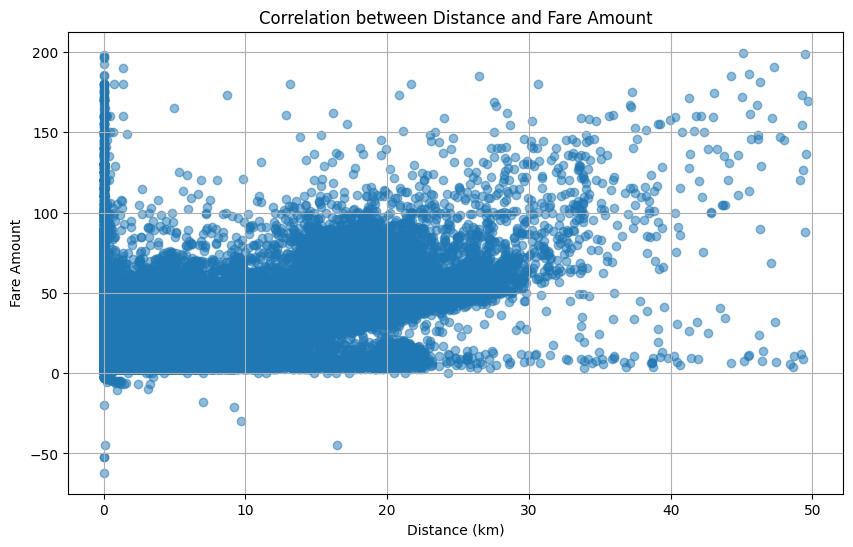

In [ ]:
""" correlation between fare_amount and distance """
plt.figure(figsize=(10, 6))
filtered_df = df_with_datetime_features[df_with_datetime_features['distance'] < 50]
filtered_df1 = filtered_df[filtered_df['fare_amount'] < 200]

plt.scatter(filtered_df1['distance'], filtered_df1['fare_amount'], alpha=0.5)
plt.title('Correlation between Distance and Fare Amount')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount')
plt.grid(True)
plt.show()

In [ ]:
df_with_datetime_features.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,dow,hour,month,year,distance
0,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1,0,17,6,2009,1.030764
1,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1,1,16,1,2010,8.450134
2,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2,3,0,8,2011,1.389525
3,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1,5,4,4,2012,2.799270
4,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1,1,7,3,2010,1.999157


In [ ]:
""" correlation between fare_amount and distance """
plt.figure(figsize=(10, 6))
plt.scatter(df_with_datetime_features['fare_amount'], df_with_datetime_features['distance'],alpha=0.5)
plt.title('Correlation between  and Fare Amount and distance')
plt.ylabel('Distance (km)')
plt.xlabel('Fare Amount')
plt.grid(True)
plt.show()

In [ ]:
# Correlation between distance and fare_amount is:

In [ ]:
distance_series = ddf['distance']
fare_amount_series = ddf['fare_amount']
type(distance_series)
type(fare_amount_series)

In [ ]:
distance_series_pandas = distance_series.compute()
fare_amount_series_pandas = fare_amount_series.compute()
type(distance_series_pandas)

In [ ]:
type(fare_amount_series_pandas)

In [ ]:
correlation = distance_series_pandas.corr(fare_amount_series_pandas)

In [ ]:
print("Correlation between distance and fare amount is ",correlation)

In [ ]:
# The magnitude of the correlation coefficient indicates the strength of the relationship. Since 0.025 is very close to 0, it indicates that the relationship between distance and fare amount is extremely weak

### Preparing dataset for model implementation

**Note:** Use the above modified dataset for modelling.

In [ ]:
# YOUR CODE HERE

### Removing outliers from training set Based on Coordinates (1 Point)

#### Exercise 8: Remove the outliers using the given latitude and longitude features from the dataset. We need to analyze the data of taxi within New York City.

**Hint:** Given the co-ordinates of New York city are Latitude: 40.7128° and Longitude: -74.0060°. You can include the pickup and drop off points such that there left and right value mean will be the given co-ordinate value.

Also, choose nearest extreme values.

Use `.between()` and pass left and right value attributes accordingly.

In [ ]:
import dask.dataframe as dd


def remove_nyc_taxi_outliers(ddf, nyc_latitude=40.7128, nyc_longitude=-74.0060, margin_of_error=0.1):
  """
  Filters a Dask DataFrame containing NYC taxi data to remove outliers based on latitude and longitude.

  Args:
      ddf (dask.dataframe.DataFrame): The Dask DataFrame containing taxi trip data.
      nyc_latitude (float, optional): The reference latitude for New York City. Defaults to 40.7128.
      nyc_longitude (float, optional): The reference longitude for New York City. Defaults to -74.0060.
      margin_of_error (float, optional): The margin of error for considering data points as outliers. Defaults to 0.1 degrees.

  Returns:
      dask.dataframe.DataFrame: A new Dask DataFrame containing only rows within the specified latitude and longitude ranges.
  """

  # Calculate acceptable latitude and longitude ranges
  left_latitude = nyc_latitude - margin_of_error
  right_latitude = nyc_latitude + margin_of_error
  left_longitude = nyc_longitude - margin_of_error
  right_longitude = nyc_longitude + margin_of_error

  # Filter rows within acceptable ranges for pickup and dropoff locations
  filtered_ddf = ddf[
      (ddf['pickup_latitude'].between(left_latitude, right_latitude)) &
      (ddf['pickup_longitude'].between(left_longitude, right_longitude)) &
      (ddf['dropoff_latitude'].between(left_latitude, right_latitude)) &
      (ddf['dropoff_longitude'].between(left_longitude, right_longitude))
  ]

  return filtered_ddf


In [ ]:
# Remove outliers with a margin of error of 0.1 degrees
filtered_ddf = remove_nyc_taxi_outliers(ddf)

# Explore the number of rows before and after filtering (optional)
# print("Number of rows in original DataFrame:", ddf.npartitions * len(ddf.compute()))
# print("Number of rows in filtered DataFrame:", filtered_ddf.npartitions * len(filtered_ddf.compute()))


In [ ]:
type(filtered_ddf)

In [ ]:
print(filtered_ddf.size.compute())

In [ ]:
ddf = filtered_ddf

In [ ]:
print(ddf.size.compute())

### Modelling (3 Points)

#### Exercise 9: Divide the data into train and test splits with X as feature variables and y as target variable

* Divide data into train test split with 70-30 ratio, Hint: `train_test_split()`

* As dask functions operate lazily so, before calling `.fit()` function, call the dask dataframe with `.compute()`.
* Convert X_train and y_train into array using `.values` as [dask's](https://ml.dask.org/modules/api.html) `.fit()` function takes array as attribute

In [ ]:
ddf.head()

In [ ]:
ddf = ddf.drop('pickup_datetime', axis=1)

In [ ]:
ddf.head()

In [ ]:
import dask.dataframe as dd
from dask_ml.model_selection import train_test_split
import numpy as np  # For array conversion

# Assuming your Dask DataFrame is named 'ddf'
features = ddf.drop('fare_amount', axis=1)  # Drop fare_amount to create features (X)
y = ddf['fare_amount']  # Extract fare_amount as target variable (y)




In [ ]:
from dask_ml.model_selection import train_test_split

# Split data with 70% for training and 30% for testing
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.3, random_state=42)

In [ ]:
type(X_train)

dask.dataframe.core.DataFrame

In [ ]:
X_train

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,dow,hour,month,year,distance
npartitions=2,,,,,,,,,,
0,float64,float64,float64,float64,int64,int32,int32,int32,int32,float64
333333,...,...,...,...,...,...,...,...,...,...
670184,...,...,...,...,...,...,...,...,...,...


In [ ]:
# Force computation before fitting the model (important for Dask)
X_train = X_train.compute()
# X_test = X_test.compute()
# y_train = y_train.compute()
# y_test = y_test.compute()

# Convert to NumPy arrays for model training (.fit() expects arrays)
# X_train = X_train.values
# X_test = X_test.values
# y_train = y_train.values
# y_test = y_test.values

# # Now you can use X_train, X_test, y_train, and y_test for model training and evaluation
# print("X_train shape:", X_train.shape)
# print("X_test shape:", X_test.shape)
# print("y_train shape:", y_train.shape)
# print("y_test shape:", y_test.shape)

In [ ]:
y_train = y_train.compute()

#### Exercise 10: Predict the test data and calculate the mean squared error and r2 score.

**Hint:** Remember to call `.compute()` function as dask functions operate lazily and convert the dask dataframe to `.values` (Array type) as suggested in above exercise

In [ ]:
from dask_ml.linear_model import LinearRegression

# Define the model (replace with your preferred model)
model = LinearRegression()

In [ ]:
model.fit(X_train.values, y_train.values)

LinearRegression()

In [ ]:
# Call .compute() to force prediction on actual data (important for Dask)
predictions = model.predict(X_test.compute().values)



In [ ]:
type(y_test), type(predictions)

(dask.array.core.Array, numpy.ndarray)

In [ ]:
y_test.shape, predictions.shape

((600366, 1), (600366,))

In [ ]:
y_test = y_test.to_dask_array(lengths = True)


In [ ]:
y_test = y_test.reshape(-1)

In [ ]:
type(y_test)

dask.array.core.Array

In [ ]:
y_test.compute()

array([16.9,  4.1,  5.7, ..., 19.7,  6.1,  9.5])

In [ ]:
# Calculate mean squared error (MSE)
mse = mean_squared_error(y_test, predictions)

# Calculate R-squared score
r2 = r2_score(y_test, predictions)

# Print the results
print("Mean Squared Error (MSE):", mse)
print("R-squared Score:", r2)

Mean Squared Error (MSE): 97.16772199616162
R-squared Score: 0.015952462557844327


In [ ]:
""" predict the values """
# YOUR CODE HERE
import dask.dataframe as dd
from dask_ml.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor  # Replace with your chosen model
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np  # For array conversion

# Assuming your Dask DataFrame is named 'ddf' and you have features ('X_test') and target ('y_test') arrays

# Define the model (replace with your preferred model)
model = LinearRegression()

model.fit(X_train, y_train)
# Call .compute() to force prediction on actual data (important for Dask)
predictions = model.predict(X_test.compute())

# Calculate mean squared error (MSE)
mse = mean_squared_error(y_test, predictions)

# Calculate R-squared score
r2 = r2_score(y_test, predictions)

# Print the results
print("Mean Squared Error (MSE):", mse)
print("R-squared Score:", r2)


In [ ]:
""" compute mean squared error and r2_score """
# YOUR CODE HERE

### Report Analysis
* Discuss the pros and cons of using dask
* Derive the insights and discuss
* Comment on the performance metrics (MSE, $R^2$ score)
